<hr/>
<b>Nombre</b>:Mateo Bustamante Moreno
<br/>
<b>Cédula</b>:1001228880



## Enunciado

**Objetivo**: El objetivo de este proyecto es poner en práctica temas sobre el tensor de esfuerzos y el tensor de deformación.

**Procedimiento**:

Un bloque metálico de 2 metros por 1 metro, con 0.2 metros de espesor, esta sometido a un campo de desplazamientos dado por la siguiente expresión:

  $$
  \begin{array}{ll}
x & =X+0.001 Y+0.0002 X^2 - 0.002 Z \\
y & =1.001 Y-0.0002 Y^2 + 0.004 Z \\
z& = 0.0003 X^2 + 0.0004 Y + 0.998 Z
\end{array}
  $$

1. Hacer un mapa de campo vectorial mostrando los vectores de desplazamiento $\vec u$ en la lamina. Es decir, sobre una malla de valores de las coordenadas eulerianas $X, Y$ dibujar el valor del vector de desplazamiento proyectado sobre ese plano $(u_x, u_y)$ para un valor de z específico. Crear un código interactivo que permita, variando el valor de $z$, ver el campo de desplazamientos en la lámina. Hacer lo mismo para cortes en el plano $X-Z$ y $Y-Z$.

2. Calcular el campo tensorial de deformaciones (pequeñas) dentro de la lámina, $u_{ij}$ como función de $\vec X$. Si se diagonaliza el tensor de deformaciones, es posible encontrar en cada punto las denominadas deformaciones principales (autovalores del tensor), $\epsilon_1, \epsilon_2, \epsilon_3$ (de menor a mayor de acuerdo con su valor absoluto) y las direcciones principales de deformación (autovectores normalizados), $\hat e_{u1}, \hat e_{u2}, \hat e_{u3}$. Escriba un código interactivo que permita variar el valor de $X, Y, Z$ y que muestre, en un gráfico en 3-D, las direcciones principales de deformación (son 3 vectores ortogonales) en ese punto de la lámina, de modo que el tamaño de cada vector sea proporcional al valor absoluto de la deformación principal correspondiente. Juegue con el código y comente lo que observa.

3. Consulte el módulo de Young $E$ y el coeficiente de Poisson del Aluminio $\nu$ y, usando la ley de Hooke (relación constitutiva), calcule el tensor de esfuerzos en cada punto del bloque (campo tensorial de esfuerzos) y la presión (campo escalar de presión). Ambos campos deben escribirse como función de $X, Y, Z$. Haga un interactivo en el que muestre, variando el valor de z, un gráfico de contornos (o mapa de calor) de la presión experimentada a cada profundidad dentro del bloque. ¿En que punto del bloque se experimenta la máxima presión y cuánto vale?.

4. Calcule el tensor de esfuerzos en el centro del bloque. Diagonalizando el tensor, determine los esfuerzos principales (autovalores del tensor), $\sigma_1, \sigma_2, \sigma_3$ y las direcciones de los esfuerzos principales (autovectores del tensor normalizados) $\hat e_{\sigma1}, \hat e_{\sigma2}, \hat e_{\sigma3}$. Ahora aplique una rotación del tensor de esfuerzos en ese punto y demuestre que el tensor rotado tiene forma diagonal. Repita el procedimiento de rotación a todos los puntos del bloque y usando esos tensores de esfuerzos rotados, repita 3 (mapas de calor de la presión en el bloque y lugar donde la presión es más grande).

5. Determine el valor del vector de esfuerzo normal (tracción sobre la cara, $\vec t_n = \mathbf{\sigma}\cdot\hat n$) que experimenta el bloque en cada una de sus 6 caras y el esfuerzo normal correspondiente ($\sigma_n = \vec t_n\cdot\hat n$). Haga gráficos de contorno (mapas de calor) para el valor del esfuerzo normal en cada uno de los puntos de esas caras. Comente su resultado.  Calcule también el valor del vector de esfuerzo de cizalladura en cada una de las 3 caras ($\vec\tau_n = \vec t_n - \sigma_n\hat n$) y haga mapas de campo vectorial de esos vectores en cada una de ellas.


## Solución

---
#**NOTA: si no funciona el interactivo es necesario correr el código.**
---

Importamos las librerias necesarias

In [ ]:
!pip install -q ipywidgets

In [ ]:
import numpy as np
import sympy as sp
import ipywidgets as widgets
import matplotlib.pyplot as plt

from ipywidgets import interact, interact_manual

#**PUNTO 1**

Plano **X-Y**

In [ ]:
def plano_xy(Z):
  X = np.linspace(0,2,10)
  Y = np.linspace(0,1,10)

  X_xy,Y_xy = np.meshgrid(X,Y)

  ##Vectores de desplazamiento
  u_x = X_xy + 0.001*Y_xy + 0.0002*X_xy**2 - 0.002*Z - (X_xy)
  u_y = 1.001*Y_xy - 0.0002*Y_xy**2 + 0.004*Z - (Y_xy)

#---------------------------------------------
#Gráfico
  fig,ax = plt.subplots()

  ax.quiver(X_xy,Y_xy,u_x,u_y)
  plt.show()

interact(plano_xy, Z=(0,0.2,0.01))

interactive(children=(FloatSlider(value=0.1, description='Z', max=0.2, step=0.01), Output()), _dom_classes=('w…

<function __main__.plano_xy(Z)>

Plano **X-Z**

In [ ]:
def plano_xz(Y):
  X = np.linspace(0,2,10)
  Z = np.linspace(0,0.2,10)

  X_xz,Z_xz = np.meshgrid(X,Z)

  ##Vectores de desplazamiento
  u_x2 = X_xz + 0.001*Y + 0.0002*X_xz**2 - 0.002*Z_xz - (X_xz)
  u_z2 = 0.0003*X_xz**2 + 0.0004*Y + 0.998*Z_xz - (Z_xz)

#---------------------------------------------
#Gráfico
  fig,ax = plt.subplots()

  ax.quiver(X_xz,Z_xz,u_x2,u_z2)
  plt.show()

interact(plano_xz, Y=(0,1,0.1))

interactive(children=(FloatSlider(value=0.0, description='Y', max=1.0), Output()), _dom_classes=('widget-inter…

<function __main__.plano_xz(Y)>

Plano **Y-Z**

In [ ]:
def plano_yz(X):

  Y = np.linspace(0,1,10)
  Z = np.linspace(0,0.2,10)

  Y_yz,Z_yz = np.meshgrid(Y,Z)

  ##Vectores de desplazamiento
  u_y3 = 1.001*Y_yz - 0.0002*Y_yz**2 + 0.004*Z_yz - (Y_yz)
  u_z3 = 0.0003*X**2 + 0.0004*Y_yz + 0.998*Z_yz - (Z_yz)

#---------------------------------------------
#Gráfico
  fig,ax = plt.subplots()

  ax.quiver(Y_yz,Z_yz,u_y3,u_z3)
  plt.show()

interact(plano_yz, X=(0,2,0.2))

interactive(children=(FloatSlider(value=1.0, description='X', max=2.0, step=0.2), Output()), _dom_classes=('wi…

<function __main__.plano_yz(X)>

#**PUNTO 2**

Para hallar el campo tensorial de deformaciones $u_{ij}$ como función de $\vec X$, se hará uso de la libreria sympy, esto para realizar todas las operaciones y cuando se quiera hallar el valor del campo en un punto específico solo es reemplazar las posiciones inciales en la función.

In [ ]:
X, Y, Z = sp.symbols("X Y Z", real=True)

##Vectores de desplazamiento
u_x = X + 0.001*Y + 0.0002*X**2 - 0.002*Z - (X)
u_y = 1.001*Y - 0.0002*Y**2 + 0.004*Z - (Y)
u_z = 0.0003*X**2 + 0.0004*Y + 0.998*Z - (Z)


Lo que se hará en el siguiente ciclo for será hallar una parte del tensor de deformación, especificamente $\nabla_i u_j$

In [ ]:
#Matriz auxiliar
M = sp.Matrix([[0,0,0], [0,0,0],[0,0,0]])

#listas de ayuda para realizar la derivada de cada vector de desplazamiento con
#respecto a cada variable (X,Y,Z)
Despla = [u_x,u_y,u_z]
Var = [X,Y,Z]


for i in enumerate(Despla):
  for j in enumerate(Var):
    M[i[0],j[0]] = sp.diff(i[1],j[1])


#campo de deformación
u_ij = sp.Rational(1,2)*(M + M.T)
u_ij

Matrix([
[        0.0004*X,                         0.0005, 0.0003*X - 0.001],
[          0.0005, 0.00099999999999989 - 0.0004*Y,           0.0022],
[0.0003*X - 0.001,                         0.0022,           -0.002]])

**IMPORTANTE** Vemos que el tensor de deformaciones no depende de **Z**, algo que será importante a partir de ahora en cada uno de los cálculos, ya que no se tendrá en cuenta la variación en este eje.

Ya tenemos el tensor de deformación en función de $\vec X$, ahora se realizará el código interactivo.

In [ ]:
def deformaciones(x,y,z):
    #Pasamos de sympy a numpy, ya reemplazando los valores de X,Y
    tensor_def = np.array(u_ij.subs([(X,x), (Y,y)]), dtype = float)
    #Hallamos los autovalores y autovectores
    autovalores, autovectores = np.linalg.eig(tensor_def)

    #Esto me ordenará los autovectores de menor a mayor
    new_indices = np.argsort(np.abs(autovalores))
    new_autovalores = autovalores[new_indices]
    new_autovectores = autovectores[:, new_indices]


    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for i in range(0,3):
      #tamaño de cada vector proporcional al valor absoluto de la deformación.
      escala = np.abs(new_autovalores[i])*100
      ax.quiver(x, y, z,
                new_autovectores[0,i],
                new_autovectores[1,i],
                new_autovectores[2,i],
                length = escala,
                normalize=True)

    ax.set_xlim(0,2)
    ax.set_ylim(0,1)
    ax.set_zlim(0,0.2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    plt.show()

#interactivo
interact(deformaciones, x=(0,2,0.2), y=(0,1,0.1), z=(0,0.2,0.02))

interactive(children=(FloatSlider(value=1.0, description='x', max=2.0, step=0.2), FloatSlider(value=0.0, descr…

<function __main__.deformaciones(x, y, z)>

Cuando se dejan los ejes fijos se observa que las direcciones principales de deformación son constantes a lo largo de la lámina, aunque cuando no se dejan los ejes fijos se observa una pequeña variación (Casi imperceptible) en las direcciónes de los vectores.

#**PUNTO 3**

Tensor de deformación

In [ ]:
u_ij

Matrix([
[        0.0004*X,                         0.0005, 0.0003*X - 0.001],
[          0.0005, 0.00099999999999989 - 0.0004*Y,           0.0022],
[0.0003*X - 0.001,                         0.0022,           -0.002]])

Para usar la ley de Hooke (relación constitutiva), solo se necesitan ciertas componentes del tensor de deformación.

In [ ]:
u_ij_h = sp.zeros(6,1)
for i in range(3):
  u_ij_h[i] = u_ij[i,i]

u_ij_h[3] = 2*u_ij[0,1]
u_ij_h[4] = 2*u_ij[0,2]
u_ij_h[5] = 2*u_ij[1,2]
u_ij_h


Matrix([
[                      0.0004*X],
[0.00099999999999989 - 0.0004*Y],
[                        -0.002],
[                         0.001],
[              0.0006*X - 0.002],
[                        0.0044]])

In [ ]:
#Módulo de young
E = 70 #Gpa
#coeficiente de poisson
nu = 0.33

#Matriz de la Relación constitutiva
rel_const = sp.Matrix([[1-nu,nu,nu,0,0,0],
                        [nu,1-nu,nu,0,0,0],
                        [nu,nu,1-nu,0,0,0],
                        [0,0,0,(1-2*nu)/2,0,0],
                        [0,0,0,0,(1-2*nu)/2,0],
                        [0,0,0,0,0,(1-2*nu)/2]])

#Ley de Hooke
sigma = E/((1-2*nu)*(1+nu))*rel_const*u_ij_h

sigma

Matrix([
[ 0.0414860681114551*X - 0.0204334365325077*Y - 0.0510835913312751],
[0.0204334365325077*X - 0.0414860681114551*Y + 0.00154798761608756],
[  0.0204334365325077*X - 0.0204334365325077*Y - 0.156346749226012],
[                                               0.0263157894736842],
[                        0.0157894736842105*X - 0.0526315789473684],
[                                                0.115789473684211]])

Con la variable "$Sigma$" hallamos ciertas componentes del tensor de esfuerzos, ahora por simetría terminaremos de completar el tensor.

In [ ]:
tensor_esf = sp.eye(3)
for i in range(3):
    tensor_esf[i,i] = sigma[i]


tensor_esf[0,1] = tensor_esf[1,0] = sigma[3]
tensor_esf[0,2] = tensor_esf[2,0] = sigma[4]
tensor_esf[1,2] = tensor_esf[2,1] = sigma[5]

tensor_esf



Matrix([
[0.0414860681114551*X - 0.0204334365325077*Y - 0.0510835913312751,                                                0.0263157894736842,                       0.0157894736842105*X - 0.0526315789473684],
[                                              0.0263157894736842, 0.0204334365325077*X - 0.0414860681114551*Y + 0.00154798761608756,                                               0.115789473684211],
[                       0.0157894736842105*X - 0.0526315789473684,                                                 0.115789473684211, 0.0204334365325077*X - 0.0204334365325077*Y - 0.156346749226012]])

Con el tensor de esfuerzos podemos hallar la presión, esta expresión estará en funcion de $\vec X$

In [ ]:
presion = -sp.Rational(1,3)*tensor_esf.trace()
presion

-0.0274509803921569*X + 0.0274509803921569*Y + 0.0686274509803998

Procedemos a realizar el gráfico de contornos.

En la siguiente linea de código hay dos ciclos que me ayudarán a calcular la presión en cada punto, encima de estos ciclos se encuentra una expresión comentada que sería el procedimiento ideal a seguir pero no funciona por un problema de iteraciones de la libreria "Sympy", por tanto estos ciclos haran el trabajo que debería realizar la linea comentada.

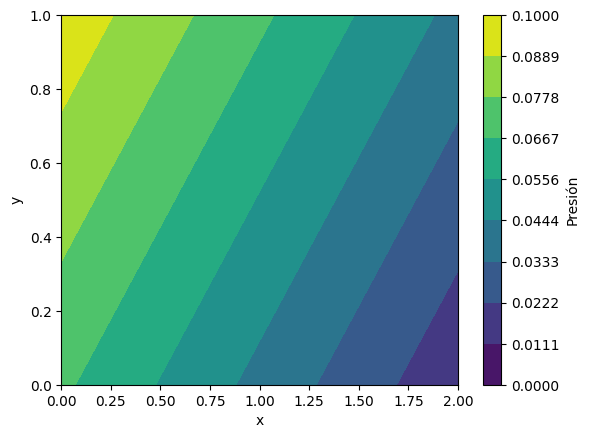

In [ ]:
X2 = np.linspace(0,2,10)
Y2 = np.linspace(0,1,10)

x,y = np.meshgrid(X2,Y2)

#P = presion.subs([(X,x), (Y,y)]) No funciona
P = np.zeros((10,10))
for i in range(10):
  for j in range(10):
    P[i,j] = presion.subs([(X,x[i][j]), (Y,y[i][j])])

c = plt.contourf(x,y,P,levels=np.linspace(0,0.1,10))
cbar = plt.colorbar(c)
cbar.set_label('Presión')
plt.xlabel("x")
plt.ylabel("y")

plt.show()

Observamos que el punto de mayor presión es en la esquina superior izquierda, las coordenadas corresponden a X,Y = (0,1). Recordemos que no hay variación en el eje Z.

#**PUNTO 4**

Diagonalizamos el tensor de esfuerzos, con esto obtenemos los autovectores, en vez de usar la libreria Sympy mejor usamos la función $np.linalg.eig$ debido a que nos entrega los autovectores ya normalizados.

La matriz de autovectores $P$ corresponderá a la matriz de rotación, y para hallar el tensor de esfuerzos rotado haremos lo siguiente:

$$
 P^T \sigma P = \sigma_{rot}
$$

In [ ]:
def rotacion(x,y):

  #hallamos los autovectores y autovalores del tensor de esfuerzos
  tensor = np.array(tensor_esf.subs([(X,x), (Y,y)]), dtype = float)
  autovalores, autovectores = np.linalg.eig(tensor)

  #Tensor de esfuerzos rotado
  tensor_rot = autovectores.T@tensor@autovectores
  #Presión en el tensor de esfuerzos rotado
  presion = -1/3*tensor_rot.trace()

  return tensor_rot, presion

Aplicamos una rotación al tensor de esfuerzos en el centro de la lámina, es decir, coordenadas X,Y = (1,0.5), y vemos que tiene forma diagonal.

In [ ]:
rotacion(1,0.5)[0]

array([[-2.19804485e-01,  2.08166817e-17,  4.16333634e-17],
       [ 1.88651178e-17, -1.00692544e-02,  7.58941521e-18],
       [ 3.46944695e-17,  9.54097912e-18,  6.51678571e-02]])

Rotamos todos los puntos del bloque y hallamos la presión.

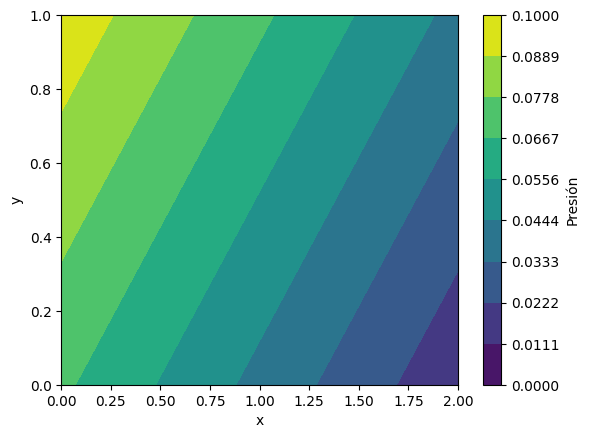

In [ ]:
X2 = np.linspace(0,2,10)
Y2 = np.linspace(0,1,10)

x,y = np.meshgrid(X2,Y2)


Presion = np.zeros((10,10))
for i in range(10):
  for j in range(10):
    Presion[i,j] = rotacion(x[i][j],y[i][j])[1]


c = plt.contourf(x,y,Presion,levels=np.linspace(0,0.1,10))
cbar = plt.colorbar(c)
cbar.set_label('Presión')
plt.xlabel("x")
plt.ylabel("y")

plt.show()

Se observa que a pesar de que las componentes del tensor de esfuerzos cambian, la magnitud de la presión no varía, además, en este caso particular se mantienen las direcciones, esto debido a que estamos en el sistema de referencia del bloque rotado, por lo que realmente la dirección si varía.

#**PUNTO 5**

Crearemos una función que nos devolverá el valor del esfuerzo normal en cada punto y el vector de esfuerzo de cizalladura para cada valor.

In [ ]:
def esfNormal(M,x,y):

  vec_normal = M
  tensor_esfuerzos = tensor_esf.subs([(X,x), (Y,y)])
  traccion_vec = tensor_esfuerzos@vec_normal

  tensor_esf_normal = traccion_vec.dot(vec_normal)

  vec_esf_cizalladura = traccion_vec - tensor_esf_normal*vec_normal

  return float(tensor_esf_normal),vec_esf_cizalladura

Bloque metálico con el respectivo sistema de referencia usado:

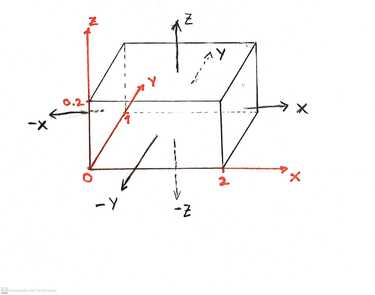

Cara sobre el plano XY, El vector normal será en dirección -z, es decir, (0,0,-1)

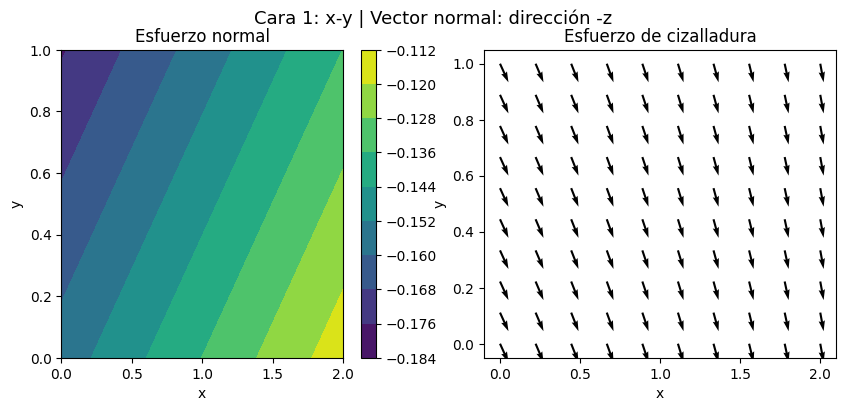

In [ ]:
X2 = np.linspace(0,2,10)
Y2 = np.linspace(0,1,10)

x,y = np.meshgrid(X2,Y2)

#Vector normal a la respectiva cara.
M = sp.Matrix([[0],[0],[-1]])

#Matriz que me almacenarán los valores del esfuerzo normal en cada punto.
Tensor_esf_n = np.zeros((10,10))
#Matrices que me almacenarán los esfuerzos de cizalladura en cada eje.
eje_x = np.zeros((10,10))
eje_y = np.zeros((10,10))

for i in range(10):
  for j in range(10):
    Tensor_esf_n[i,j], cizalladura = esfNormal(M,x[i][j],y[i][j])

    eje_x[i,j] = float(cizalladura[0])
    eje_y[i,j] = float(cizalladura[1])


#------------------------------------------
# gráfico de contorno para el valor del esfuerzo normal.
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

c = axs[0].contourf(x,y,Tensor_esf_n)
cbar = plt.colorbar(c)
axs[0].set_title("Esfuerzo normal")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")


#-------------------------------------------
#mapa de campo vectorial para el esfuerzo de cizalladura.
axs[1].quiver(x,y,eje_x,eje_y)
axs[1].set_title("Esfuerzo de cizalladura")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")

fig.suptitle('Cara 1: x-y | Vector normal: dirección -z ', fontsize=13)
plt.show()

Cara sobre el plano XY, El vector normal será en dirección z, (0,0,1)

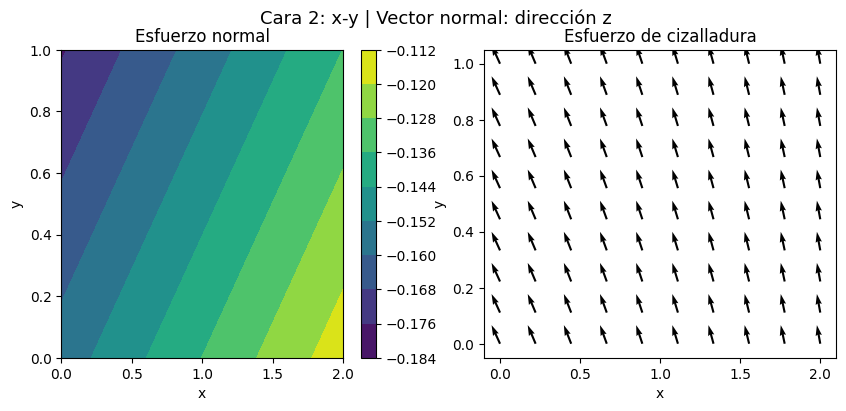

In [ ]:
X2 = np.linspace(0,2,10)
Y2 = np.linspace(0,1,10)

x,y = np.meshgrid(X2,Y2)

#Vector normal a la respectiva cara.
M = sp.Matrix([[0],[0],[1]])

#Matriz que me almacenarán los valores del esfuerzo normal en cada punto.
Tensor_esf_n = np.zeros((10,10))
#Matrices que me almacenarán los esfuerzos de cizalladura en cada eje.
eje_x = np.zeros((10,10))
eje_y = np.zeros((10,10))

for i in range(10):
  for j in range(10):
    Tensor_esf_n[i,j],cizalladura = esfNormal(M,x[i][j],y[i][j])

    eje_x[i,j] = float(cizalladura[0])
    eje_y[i,j] = float(cizalladura[1])


#------------------------------------------
# gráfico de contorno para el valor del esfuerzo normal.
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

c = axs[0].contourf(x,y,Tensor_esf_n)
cbar = plt.colorbar(c)
axs[0].set_title("Esfuerzo normal")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")


#-------------------------------------------
#mapa de campo vectorial para el esfuerzo de cizalladura.
axs[1].quiver(x,y,eje_x,eje_y)
axs[1].set_title("Esfuerzo de cizalladura")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")


fig.suptitle("Cara 2: x-y | Vector normal: dirección z", fontsize=13)
plt.show()

Cara sobre el plano YZ, el vector normal será en dirección -x, es decir, (-1,0,0), en esta cara X valdrá siempre cero.

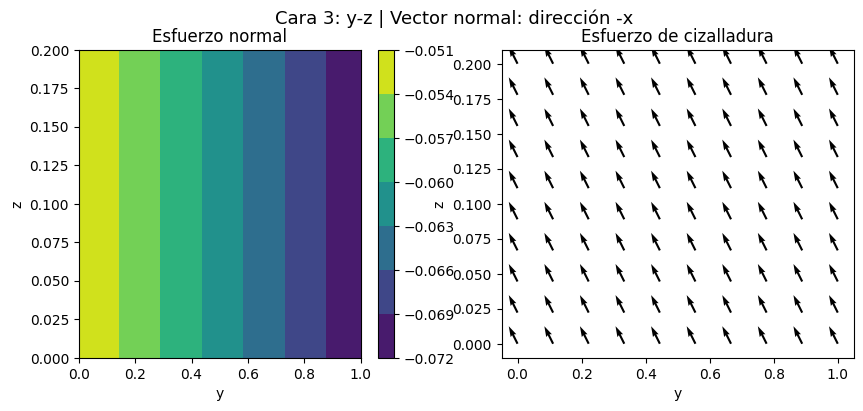

In [ ]:
Y2 = np.linspace(0,1,10)
Z2 = np.linspace(0,0.2,10)

y,z = np.meshgrid(Y2,Z2)

#Vector normal a la respectiva cara.
M = sp.Matrix([[-1],[0],[0]])

#Matriz que me almacenarán los valores del esfuerzo normal en cada punto.
Tensor_esf_n = np.zeros((10,10))
#Matrices que me almacenarán los esfuerzos de cizalladura en cada eje.
eje_y = np.zeros((10,10))
eje_z = np.zeros((10,10))

for i in range(10):
  for j in range(10):
    Tensor_esf_n[i,j],cizalladura = esfNormal(M,0,y[i][j])

    eje_y[i,j] = float(cizalladura[1])
    eje_z[i,j] = float(cizalladura[2])


#------------------------------------------
# gráfico de contorno para el valor del esfuerzo normal.
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

c = axs[0].contourf(y,z,Tensor_esf_n)
cbar = plt.colorbar(c)
axs[0].set_title('Esfuerzo normal')
axs[0].set_xlabel("y")
axs[0].set_ylabel("z")

#-------------------------------------------
#mapa de campo vectorial para el esfuerzo de cizalladura.
axs[1].quiver(y,z,eje_y,eje_z)
axs[1].set_title("Esfuerzo de cizalladura")
axs[1].set_xlabel("y")
axs[1].set_ylabel("z")


fig.suptitle("Cara 3: y-z | Vector normal: dirección -x", fontsize=13)
plt.show()

Cara sobre el plano YZ, el vector normal será en dirección x, es decir, (1,0,0), en esta cara X valdrá siempre 2.

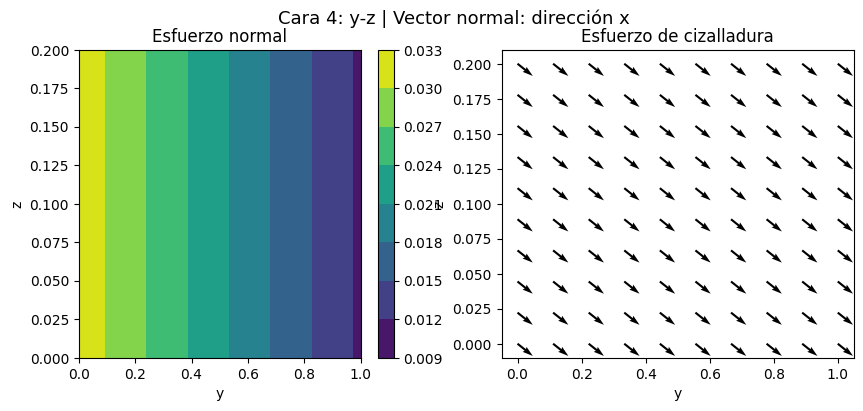

In [ ]:

Y2 = np.linspace(0,1,10)
Z2 = np.linspace(0,0.2,10)

y,z = np.meshgrid(Y2,Z2)

#Vector normal a la respectiva cara.
M = sp.Matrix([[1],[0],[0]])

#Matriz que me almacenarán los valores del esfuerzo normal en cada punto.
Tensor_esf_n = np.zeros((10,10))
#Matrices que me almacenarán los esfuerzos de cizalladura en cada eje.
eje_y = np.zeros((10,10))
eje_z = np.zeros((10,10))

for i in range(10):
  for j in range(10):
    Tensor_esf_n[i,j],cizalladura = esfNormal(M,2,y[i][j])

    eje_y[i,j] = float(cizalladura[1])
    eje_z[i,j] = float(cizalladura[2])

#------------------------------------------
# gráfico de contorno para el valor del esfuerzo normal.
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

c = axs[0].contourf(y,z,Tensor_esf_n)
cbar = plt.colorbar(c)
axs[0].set_title('Esfuerzo normal')
axs[0].set_xlabel("y")
axs[0].set_ylabel("z")

#-------------------------------------------
#mapa de campo vectorial para el esfuerzo de cizalladura.
axs[1].quiver(y,z,eje_y,eje_z)
axs[1].set_title("Esfuerzo de cizalladura")
axs[1].set_xlabel("y")
axs[1].set_ylabel("z")


fig.suptitle("Cara 4: y-z | Vector normal: dirección x", fontsize=13)
plt.show()

Cara sobre el plano XZ, el vector normal será en dirección -Y, es decir, (0,-1,0), en esta cara Y valdrá siempre cero.

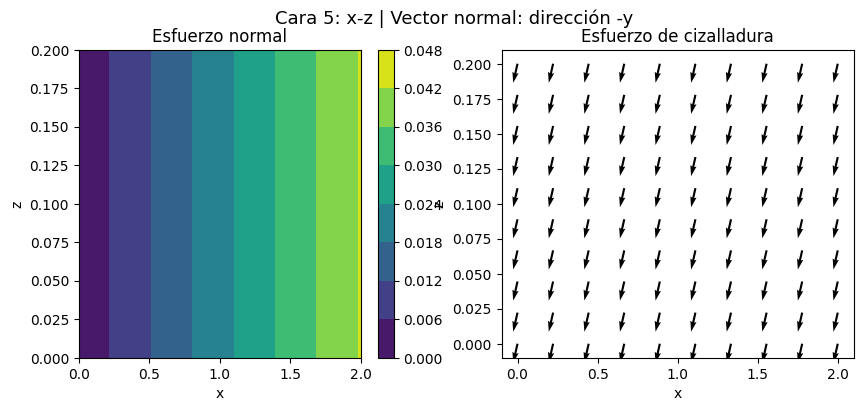

In [ ]:
X2 = np.linspace(0,2,10)
Z2 = np.linspace(0,0.2,10)

x,z = np.meshgrid(X2,Z2)

#Vector normal a la respectiva cara.
M = sp.Matrix([[0],[-1],[0]])

#Matriz que me almacenarán los valores del esfuerzo normal en cada punto.
Tensor_esf_n = np.zeros((10,10))
#Matrices que me almacenarán los esfuerzos de cizalladura en cada eje.
eje_x = np.zeros((10,10))
eje_z = np.zeros((10,10))

for i in range(10):
  for j in range(10):
    Tensor_esf_n[i,j],cizalladura = esfNormal(M,x[i][j],0)

    eje_x[i,j] = float(cizalladura[0])
    eje_z[i,j] = float(cizalladura[2])

#------------------------------------------
# gráfico de contorno para el valor del esfuerzo normal.
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

c = axs[0].contourf(x,z,Tensor_esf_n)
cbar = plt.colorbar(c)
axs[0].set_title('Esfuerzo normal')
axs[0].set_xlabel("x")
axs[0].set_ylabel("z")

#-------------------------------------------
#mapa de campo vectorial para el esfuerzo de cizalladura.
axs[1].quiver(x,z,eje_x,eje_z)
axs[1].set_title("Esfuerzo de cizalladura")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")


fig.suptitle("Cara 5: x-z | Vector normal: dirección -y", fontsize=13)
plt.show()


Cara sobre el plano XZ, el vector normal será en dirección Y, es decir, (0,1,0), en esta cara Y valdrá siempre 1.

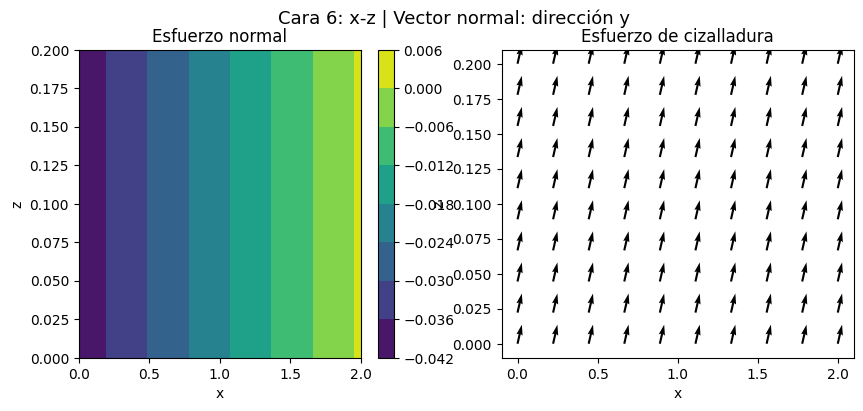

In [ ]:
X2 = np.linspace(0,2,10)
Z2 = np.linspace(0,0.2,10)

x,z = np.meshgrid(X2,Z2)

#Vector normal a la respectiva cara.
M = sp.Matrix([[0],[1],[0]])

#Matriz que me almacenarán los valores del esfuerzo normal en cada punto.
Tensor_esf_n = np.zeros((10,10))
#Matrices que me almacenarán los esfuerzos de cizalladura en cada eje.
eje_x = np.zeros((10,10))
eje_z = np.zeros((10,10))

for i in range(10):
  for j in range(10):
    Tensor_esf_n[i,j],cizalladura = esfNormal(M,x[i][j],1)

    eje_x[i,j] = float(cizalladura[0])
    eje_z[i,j] = float(cizalladura[2])

#------------------------------------------
# gráfico de contorno para el valor del esfuerzo normal.
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

c = axs[0].contourf(x,z,Tensor_esf_n)
cbar = plt.colorbar(c)
axs[0].set_title('Esfuerzo normal')
axs[0].set_xlabel("x")
axs[0].set_ylabel("z")

#-------------------------------------------
#mapa de campo vectorial para el esfuerzo de cizalladura.
axs[1].quiver(x,z,eje_x,eje_z)
axs[1].set_title("Esfuerzo de cizalladura")
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")


fig.suptitle("Cara 6: x-z | Vector normal: dirección y", fontsize=13)
plt.show()